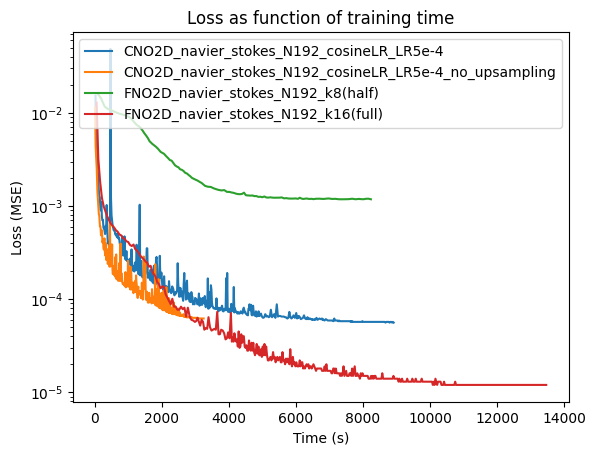

In [1]:
import numpy as np
import matplotlib.pyplot as plt

paths = ["/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N192_cosineLR_LR5e-4_no_upsampling_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N192_k8(half)_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N192_k16(full)_loss.csv"
         ]



fig, ax = plt.subplots(1)
ax.set_title("Loss as function of training time")
ax.set_yscale("log")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Loss (MSE)")

for path in paths:
    CNO_arr = np.loadtxt(path, delimiter = ",")

    CNO_time = CNO_arr[0, :]
    CNO_loss = CNO_arr[1, :]

    ax.plot(CNO_time, CNO_loss, label = path.rsplit("/",1)[-1].replace("_loss.csv", ""))

ax.legend()
plt.show()

Evaluating CNO: 100%|██████████| 9/9 [00:03<00:00,  2.34it/s]


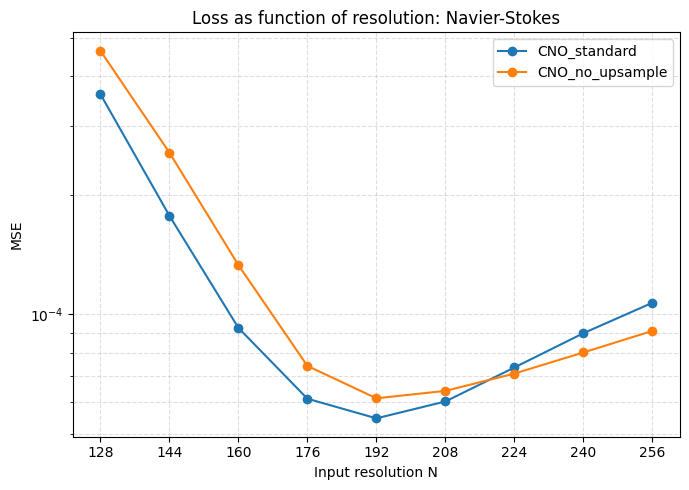

In [22]:
#plot loss as function of resolution; navier stokes

import h5py
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/mnhagen/scripts/FNO")
from tqdm import tqdm
from CNO.CNO2D_def import CNO2D
from CNO.CNO2D_def_no_upsample import CNO2D as CNO2D2
from FNO.FNO2D_def import FNO2D

# ============================================================
# CONFIG
# ============================================================
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"   
dataset_key = "omega"                        
device = "cuda:0" if torch.cuda.is_available() else "cpu"

resolutions = np.arange(128, 257, 16)
batch_size = 10
res = 192

# ============================================================
# INTERPOLATION
# ============================================================
def bicubic_resample_2d(x, out_h, out_w):
    # x: [B, C, H, W]
    return F.interpolate(
        x,
        size=(out_h, out_w),
        mode="bicubic",
        align_corners=False,
        antialias=True
    )

# ============================================================
# LOAD TEST DATA (last 200 samples)
# ============================================================
with h5py.File(h5_path, "r") as f:
    data = torch.tensor(f[dataset_key][:], dtype=torch.float32)
    # shape: [1000, 2, 256, 256]

test_data = data[800:]            # last 200 samples
u0 = test_data[:, 0:1]            # [B,1,256,256]
uT = test_data[:, 1:2]

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_model(model, model_type):
    """
    model_type: "CNO" or "FNO"
    """
    model.eval()
    model.to(device)

    losses = []

    with torch.no_grad():
        for N in tqdm(resolutions, desc=f"Evaluating {model_type}"):

            mse_sum = 0.0
            count = 0

            for i in range(0, u0.shape[0], batch_size):
                x = u0[i:i+batch_size].to(device)
                y = uT[i:i+batch_size].to(device)


                if model_type == "FNO":
                    #x = x.permute(0,2,3,1)
                    xN = bicubic_resample_2d(x, N, N)
                    pred = model(xN)
                    pred = pred.permute(0,3,1,2)

                elif model_type == "CNO":
                    xN = bicubic_resample_2d(x, N, N)
                    pred = model(xN)

                yN = bicubic_resample_2d(y, N, N)

                if pred.shape[-1] != N:
                    pred = bicubic_resample_2d(pred, N, N)

                mse = F.mse_loss(pred, yN, reduction="sum")
                mse_sum += mse.item()
                count += pred.numel()

            losses.append(mse_sum / count)

    return np.array(losses)

#Load models

width = 128
FNO_k8_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k8(half).pt"

FNO_k8 = FNO2D(8, 8, width)
FNO_k8.q = torch.nn.Conv2d(width, 1, 1)
FNO_k8.load_state_dict(torch.load(FNO_k8_path, map_location=device))
FNO_k8 = FNO_k8.to(device).eval()

FNO_k16_path = f"/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N{res}_k16(full).pt"

FNO_k16 = FNO2D(16, 16, width)
FNO_k16.q = torch.nn.Conv2d(width, 1, 1)
FNO_k16.load_state_dict(torch.load(FNO_k16_path, map_location=device))
FNO_k16 = FNO_k16.to(device).eval()

CNO_path = f"/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N{res}_cosineLR_LR5e-4.pt"
N_layers = 4
N_res    = 4
N_res_neck = 4
channel_multiplier = 16

CNO = CNO2D(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = res,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

CNO.load_state_dict(torch.load(CNO_path, map_location = device))

CNO_no_upsampling_path = f"/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N{res}_cosineLR_LR5e-4_no_upsampling.pt"

CNO_no_upsampling = CNO2D2(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = res,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

CNO_no_upsampling.load_state_dict(torch.load(CNO_no_upsampling_path, map_location = device))
CNO_no_upsampling = CNO_no_upsampling.to(device).eval()






models = {
    "FNO_k8": (FNO_k8, "FNO"),
    "FNO_k16": (FNO_k16, "FNO"),
    "CNO_standard": (CNO, "CNO"),
    "CNO_no_upsample": (CNO_no_upsampling, "CNO"),
}

results = {}

for name, (model, mtype) in models.items():
    results[name] = evaluate_model(model, mtype)

#Plot model comparison

plt.figure(figsize=(7,5))

for name, losses in results.items():
    plt.plot(resolutions, losses, marker="o", label=name)

plt.yscale("log")

plt.xlabel("Input resolution N")
plt.xticks(resolutions, resolutions)
plt.ylabel("MSE")
plt.title("Loss as function of resolution: Navier-Stokes")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


#DI value

train_idx = 4

def DI_log_mean_abs(loss, train_idx, eps = 1e-12):
    loss = np.asarray(loss, dtype = float)
    ref = loss[train_idx]
    return np.mean(np.abs(np.log(loss + eps) - np.log(ref + eps)))

for name, losses in results.items():
    print(f"DI value of {name}: {DI_log_mean_abs(losses, train_idx):.4f}")

Evaluating CNO: 100%|██████████| 9/9 [00:14<00:00,  1.60s/it]


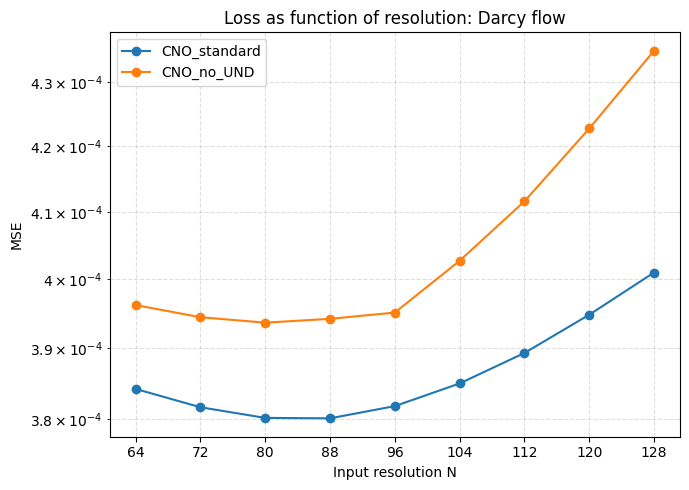

DI value of CNO_standard: 0.0140
DI value of CNO_no_UND: 0.0260


In [ ]:
#plot loss as function of resolution; darcy flow

import h5py
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/mnhagen/scripts/FNO")
from tqdm import tqdm
from CNO.CNO2D_def import CNO2D
from CNO.CNO2D_def_no_upsample import CNO2D as CNO2D2
from FNO.FNO2D_def import FNO2D

# ============================================================
# CONFIG
# ============================================================
h5_path = "/scratch/mnhagen/datasets/darcy_flow/darcy_beta1.h5"                      
device = "cuda:0" if torch.cuda.is_available() else "cpu"


batch_size = 10
res = 96
res_spacing = 8

def resolution_list(res, spacing):
    return res + spacing * np.arange(-4, 5)

resolutions = resolution_list(res, res_spacing)

# ============================================================
# INTERPOLATION
# ============================================================
def bicubic_resample_2d(x, out_h, out_w):
    # x: [B, C, H, W]
    return F.interpolate(
        x,
        size=(out_h, out_w),
        mode="bicubic",
        align_corners=False,
        antialias=True
    )

# ============================================================
# LOAD TEST DATA (last 200 samples)
# ============================================================
with h5py.File(h5_path, "r") as f:
    nu = f["nu"][:]
    tensor = f["tensor"][:]

tensor = tensor[:, 0, :, :]
data = torch.from_numpy(np.stack([nu, tensor], axis = 1))

test_data = data[8000:]
u0 = test_data[:, 0:1]
uT = test_data[:, 1:2]

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_model(model, model_type):
    """
    model_type: "CNO" or "FNO"
    """
    model.eval()
    model.to(device)

    losses = []

    with torch.no_grad():
        for N in tqdm(resolutions, desc=f"Evaluating {model_type}"):

            mse_sum = 0.0
            count = 0

            for i in range(0, u0.shape[0], batch_size):
                x = u0[i:i+batch_size].to(device)
                y = uT[i:i+batch_size].to(device)


                if model_type == "FNO":
                    #x = x.permute(0,2,3,1)
                    xN = bicubic_resample_2d(x, N, N)
                    pred = model(xN)
                    pred = pred.permute(0,3,1,2)

                elif model_type == "CNO":
                    xN = bicubic_resample_2d(x, N, N)
                    pred = model(xN)

                yN = bicubic_resample_2d(y, N, N)

                if pred.shape[-1] != N:
                    pred = bicubic_resample_2d(pred, N, N)

                mse = F.mse_loss(pred, yN, reduction="sum")
                mse_sum += mse.item()
                count += pred.numel()

            losses.append(mse_sum / count)

    return np.array(losses)

#Load models

width = 128
FNO_k8_path = f"/scratch/mnhagen/models/darcy_flow/FNO2D_darcy_flow_N{res}_k8.pt"

FNO_k8 = FNO2D(8, 8, width)
FNO_k8.q = torch.nn.Conv2d(width, 1, 1)
FNO_k8.load_state_dict(torch.load(FNO_k8_path, map_location=device))
FNO_k8 = FNO_k8.to(device).eval()

FNO_k16_path = f"/scratch/mnhagen/models/darcy_flow/FNO2D_darcy_flow_N{res}_k16.pt"

FNO_k16 = FNO2D(16, 16, width)
FNO_k16.q = torch.nn.Conv2d(width, 1, 1)
FNO_k16.load_state_dict(torch.load(FNO_k16_path, map_location=device))
FNO_k16 = FNO_k16.to(device).eval()

CNO_path = f"/scratch/mnhagen/models/darcy_flow/CNO2D_darcy_flow_N{res}.pt"
N_layers = 4
N_res    = 4
N_res_neck = 4
channel_multiplier = 16

CNO = CNO2D(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = res,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

CNO.load_state_dict(torch.load(CNO_path, map_location = device))

CNO_no_UND_path = f"/scratch/mnhagen/models/darcy_flow/CNO2D_darcy_flow_N{res}_no_UND.pt"

CNO_no_UND = CNO2D2(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = res,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

CNO_no_UND.load_state_dict(torch.load(CNO_no_UND_path, map_location = device))
CNO_no_UND = CNO_no_UND.to(device).eval()


models = {
    "FNO_k8": (FNO_k8, "FNO"),
    "FNO_k16": (FNO_k16, "FNO"),
    "CNO_standard": (CNO, "CNO"),
    "CNO_no_UND": (CNO_no_UND, "CNO"),
}


results = {}

for name, (model, mtype) in models.items():
    results[name] = evaluate_model(model, mtype)

#Plot model comparison

plt.figure(figsize=(7,5))

for name, losses in results.items():
    plt.plot(resolutions, losses, marker="o", label=name)

plt.yscale("log")

plt.xlabel("Input resolution N")
plt.xticks(resolutions, resolutions)
plt.ylabel("MSE")
plt.title("Loss as function of resolution: Darcy flow")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


#DI value

train_idx = 4

def DI_log_mean_abs(loss, train_idx, eps = 1e-12):
    loss = np.asarray(loss, dtype = float)
    ref = loss[train_idx]
    return np.mean(np.abs(np.log(loss + eps) - np.log(ref + eps)))

for name, losses in results.items():
    print(f"DI value of {name}: {DI_log_mean_abs(losses, train_idx):.4f}")

Quantify the discretization invariance: just standard deviation? avg distance from point to training resolution value DONE

explain UND block impact graphically and with experiments
statements to prove:
-behavior of CNO vs CNO_no_upsample at lower and higher resolutions
-train an FNO with UND and resample
-train new models (all 4) on the active_matter dataset

The code below shows the Fourier spectrum of the dataset at the initial condition and final state. It clearly shows that while the initial condition is bandlimited as per the Fourier generation method, the nonlinearity of the Navier Stokes time evolution widens the spectrum.

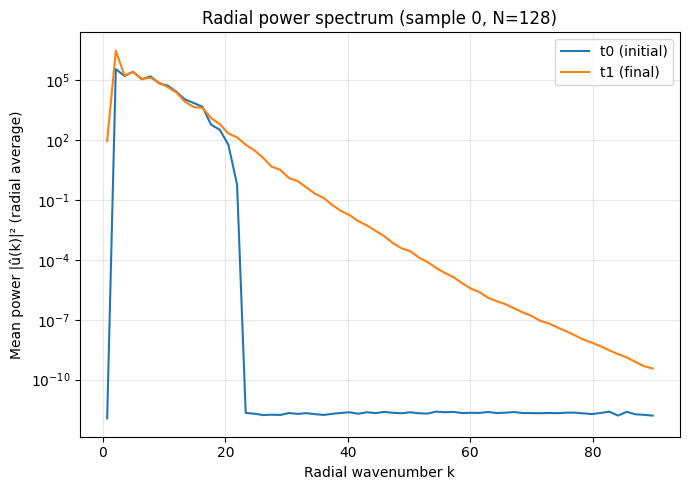

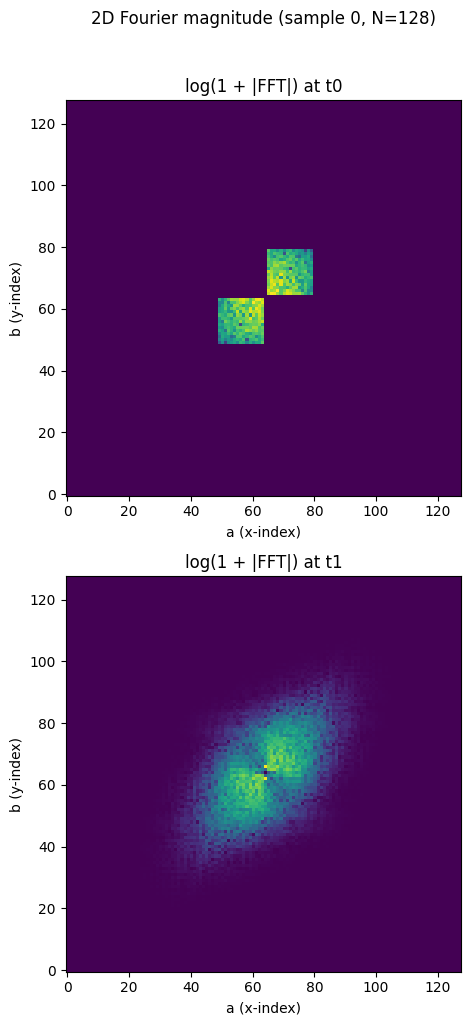

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N128_multi.h5"
dataset_key = "omega"
sample_idx = 0                        
t0_idx, t1_idx = 0, 1                               

# -----------------------
# Load one sample
# -----------------------
with h5py.File(h5_path, "r") as f:
    if dataset_key not in f:
        raise KeyError(f"'{dataset_key}' not in file. Keys: {list(f.keys())}")
    # shape: (time, N, N)
    u = f[dataset_key][sample_idx]

u0 = np.array(u[t0_idx], dtype=np.float64)
u1 = np.array(u[t1_idx], dtype=np.float64)
N = u0.shape[0]

# -----------------------
# FFT helpers
# -----------------------
def fft2_logmag(u2d: np.ndarray):
    """Centered log-magnitude of the 2D FFT."""
    U = np.fft.fft2(u2d)
    U = np.fft.fftshift(U)
    return np.log1p(np.abs(U))

def radial_power_spectrum(u2d: np.ndarray, nbins=None):
    """
    Isotropic (radially averaged) power spectrum E(k) from 2D field.
    Returns k_centers, E(k) where E(k) = mean(|FFT|^2) in radial bins.
    """
    N, M = u2d.shape
    assert N == M, "Expected square field."

    U = np.fft.fft2(u2d)
    P = np.abs(U)**2

    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    if nbins is None:
        nbins = N // 2

    kmax = K.max()
    bins = np.linspace(0.0, kmax, nbins + 1)

    Kf = K.ravel()
    Pf = P.ravel()
    idx = np.digitize(Kf, bins) - 1

    E = np.zeros(nbins, dtype=np.float64)
    counts = np.zeros(nbins, dtype=np.int64)

    valid = (idx >= 0) & (idx < nbins)
    np.add.at(E, idx[valid], Pf[valid])
    np.add.at(counts, idx[valid], 1)

    mask = counts > 0
    E[mask] /= counts[mask]

    k_centers = 0.5 * (bins[:-1] + bins[1:])
    return k_centers, E

# -----------------------
# Compute spectra
# -----------------------
logmag0 = fft2_logmag(u0)
logmag1 = fft2_logmag(u1)

k0, E0 = radial_power_spectrum(u0)
k1, E1 = radial_power_spectrum(u1)

# -----------------------
# Plot radial spectra
# -----------------------
plt.figure(figsize=(7, 5))
plt.plot(k0, E0, label="t0 (initial)")
plt.plot(k1, E1, label="t1 (final)")
plt.yscale("log")
plt.xlabel("Radial wavenumber k")
plt.ylabel("Mean power |û(k)|² (radial average)")
plt.title(f"Radial power spectrum (sample {sample_idx}, N={N})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# Plot 2D FFT log magnitude
# -----------------------
fig, ax = plt.subplots(2, 1, figsize = (7, 10))
plt.suptitle(f"2D Fourier magnitude (sample {sample_idx}, N={N})", y=1.02)
ax[0].imshow(logmag0, origin = "lower")
ax[0].set_title("log(1 + |FFT|) at t0")
ax[0].set_xlabel("a (x-index)")
ax[0].set_ylabel("b (y-index)")

ax[1].imshow(logmag1, origin="lower")
ax[1].set_title("log(1 + |FFT|) at t1")
ax[1].set_xlabel("a (x-index)")
ax[1].set_ylabel("b (y-index)")

plt.tight_layout()
plt.show()

Notes:
1. FNO learns to output any size (?) while CNO only outputs native resolution. Makes comparison harder; for the CNO, I downsampled the greatest resolution to the desired input resolution, then compared the model prediction (always 128) to the greatest resolution downsampled to match.
2. When generating data, I generated an initial condition and solved it at each of the resolutions, which was a bad decision.